# Practical - 02 - Word2Vec Exploration and Visualisation

### Train a word2vec model on a text corpus using Gensim. Test analogies and find most-similar words.
### Visualize embeddings of 50 words across different domains (sports, food, tech) using t-SNE/PCA.

In [1]:
import os
import sys

# 1. Look up one directory level from 'notebook', then go into 'visualization'
# This ensures it works no matter where you launch the notebook
base_dir = os.path.dirname(os.getcwd())
visualization_dir = os.path.join(base_dir, 'visualization')

if visualization_dir not in sys.path:
    sys.path.insert(0, visualization_dir)

In [2]:
"""Importing the Libraries"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import nltk
from gensim.utils import simple_preprocess # lowercases + tokenizes text cleanly
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from dataloader import (                     # our own module inside visualisation/
    load_corpus,          # loads CSV → DataFrame
    preprocess,           # DataFrame → token lists
    get_word_color,       # returns colour per word topic
    filter_vocab_words,   # drops words not in model vocab
    VISUAL_WORDS,         # the 50 target words
    GROUP_COLORS,         # topic → colour mapping
)

In [3]:
"""Load the dataset"""
df = load_corpus("../data/text_corpus.csv")


Loaded 80 sentences from ../data/text_corpus.csv


In [4]:
df.head() # Load first 5 columns

,text
0,The football match ended with a brilliant goal...
1,Cricket is a sport where the bat and ball defi...
2,Tennis requires a coach to improve your techni...
3,The coach trained the player every morning bef...
4,A football player needs speed and stamina to s...


In [5]:
df.shape

(80, 1)

In [6]:
df.info() # checks the detail info of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    80 non-null     object
dtypes: object(1)
memory usage: 772.0+ bytes


In [7]:
df.isnull().sum()

text    0
dtype: int64

### PreProcess the corpus data

In [8]:
"""Converting raw text rows into a list of token lists — the exact format Word2Vec expects as input."""
sentences = []
for text in df['text']:
    tokens = simple_preprocess(str(text)) # coverts into lowercase and tokenise
    sentences.append(tokens)

In [9]:
# after preprocess into lowercase and tokenising -- Sentence --> word
# eg: Cristiano Ronaldo is the greatest player. ---> ["cristiano", "Ronaldo", "is", "the", "greatest", "player"]

## Train Word2Vec

In [10]:
"""Training the Word2Vec model on preprocessed sentences.Each unique word gets a 100-dimensional vector representation."""

model = Word2Vec(
    sentences=sentences,  # the tokenized list of sentences
    vector_size=100,      # each word becomes a 100-dim vector - Embedding Size
    window=5,             # looks 5 words left and right as context
    min_count=2,          # ignores words that appear less than twice - Min word frequency
    workers=4,            # uses 4 CPU threads to speed up training
    sg=1,                 # sg=1 means Skip-Gram (sg=0 would be CBOW)
    epochs=20             # passes through the entire corpus 20 times
)
print(f"Vocab size: {len(model.wv)}")

Vocab size: 123


## Vocabulary 

In [11]:
"""Inspecting the model's vocabulary to confirm training worked."""
print(model.wv.index_to_key)   # prints the most frequent words learned

len(model.wv.index_to_key) # length of the words

['and', 'the', 'to', 'computer', 'software', 'on', 'science', 'data', 'cloud', 'are', 'with', 'internet', 'algorithm', 'monitor', 'hardware', 'network', 'is', 'in', 'server', 'math', 'student', 'milk', 'player', 'match', 'football', 'camera', 'hospital', 'school', 'phone', 'music', 'python', 'coach', 'cricket', 'by', 'keyboard', 'book', 'movie', 'ai', 'at', 'of', 'than', 'stadium', 'about', 'travel', 'doctor', 'robot', 'used', 'coffee', 'bread', 'for', 'tennis', 'mouse', 'teacher', 'using', 'cake', 'tea', 'rice', 'or', 'any', 'every', 'car', 'java', 'served', 'banana', 'apple', 'burger', 'pizza', 'most', 'from', 'together', 'was', 'your', 'both', 'better', 'servers', 'study', 'algorithms', 'use', 'through', 'build', 'running', 'uses', 'popular', 'good', 'but', 'improve', 'ball', 'bat', 'where', 'goal', 'patient', 'who', 'captures', 'be', 'must', 'like', 'developers', 'inspired', 'complete', 'has', 'recommended', 'more', 'inspire', 'can', 'resources', 'knowledge', 'design', 'written', '

123

## Explore Semantic Similarity in words

In [12]:
"""Finding words whose vectors are closest to a given word. It reveals semantic relationships the model has learned."""
# Semantic Relationships
model.wv.most_similar('car', topn=10) # returns top 10 words nearest to 'ronaldo' in vector space


[('by', 0.9966649413108826),
 ('and', 0.9966225624084473),
 ('bread', 0.9966104030609131),
 ('is', 0.9966018795967102),
 ('data', 0.9965606927871704),
 ('than', 0.996487021446228),
 ('the', 0.9964777827262878),
 ('milk', 0.9964367747306824),
 ('of', 0.9963193535804749),
 ('book', 0.996305525302887)]

In [13]:
# checking vector representation
model.wv['coffee'] # Vector represenatation

array([ 0.0216622 ,  0.00462202,  0.03212272, -0.04444985,  0.10443913,
       -0.18842526,  0.13012029,  0.21364623, -0.10313556, -0.09856315,
       -0.06019758, -0.27073318,  0.00910801,  0.12827756,  0.09458178,
       -0.04360928,  0.02255279, -0.09048834, -0.03524408, -0.2782856 ,
        0.12445521,  0.05809085,  0.04895669, -0.13701758,  0.07795058,
        0.01754214, -0.04216925, -0.07155552, -0.1199035 , -0.00629447,
        0.17202346,  0.03491041,  0.12002129, -0.19318523, -0.07747729,
        0.17411819,  0.0551859 , -0.04783338, -0.00721239, -0.13036808,
        0.08559499, -0.0816545 , -0.06222402,  0.01499468,  0.08853269,
       -0.00191328, -0.14109159, -0.04654373,  0.06330364,  0.11198812,
        0.09659843, -0.07018621,  0.01392444,  0.00730974, -0.03336642,
        0.1052854 ,  0.04326124,  0.07137455, -0.1329297 ,  0.0627974 ,
        0.04003821, -0.01447672,  0.08015146,  0.01355741, -0.11862496,
        0.16975708,  0.03232216,  0.11195843, -0.12459624,  0.17

In [14]:
# Checking similarity score of words

model.wv.similarity('cricket','football') # Similarity score

np.float32(0.99636126)

## Testing with an Analogy

In [15]:
""" Testing with famous analogy: king - man + woman = ?
This checks if the model has learned meaningful vector arithmetic."""

# king + woman - man → should land near 'queen' if training data is rich enough,
model.wv.most_similar(positive=['football', 'bat'], negative=['ball'], topn=5)

[('match', 0.9934213161468506),
 ('data', 0.9932015538215637),
 ('by', 0.9931894540786743),
 ('music', 0.9931045770645142),
 ('the', 0.992965042591095)]

## Selecting 50 words and getting embeddings

In [16]:
"""Picking 50 domain-diverse words and extracting their vectors for visualization. Words missing from the vocabulary are dropped."""

words = ['football','cricket','tennis','goal','bat','ball','coach','player','stadium','match','pizza','burger','rice','apple','banana','coffee','tea','bread','milk','cake','computer','python','java','ai','data','network','cloud','server','robot','algorithm','music','movie','book','school','teacher','student','doctor','hospital','travel','car','phone','camera','internet','software','hardware','keyboard','mouse','monitor','science','math']
words = [w for w in words if w in model.wv]          # drops any word the model never saw
vectors = np.array([model.wv[w] for w in words])     # stacks all vectors into a (N x 100) matrix
colors  = [get_word_color(w) for w in words]          # gets topic colour per word from dataloader

print(f"Ready to plot {len(words)} words")

Ready to plot 50 words


## PCA Visualization

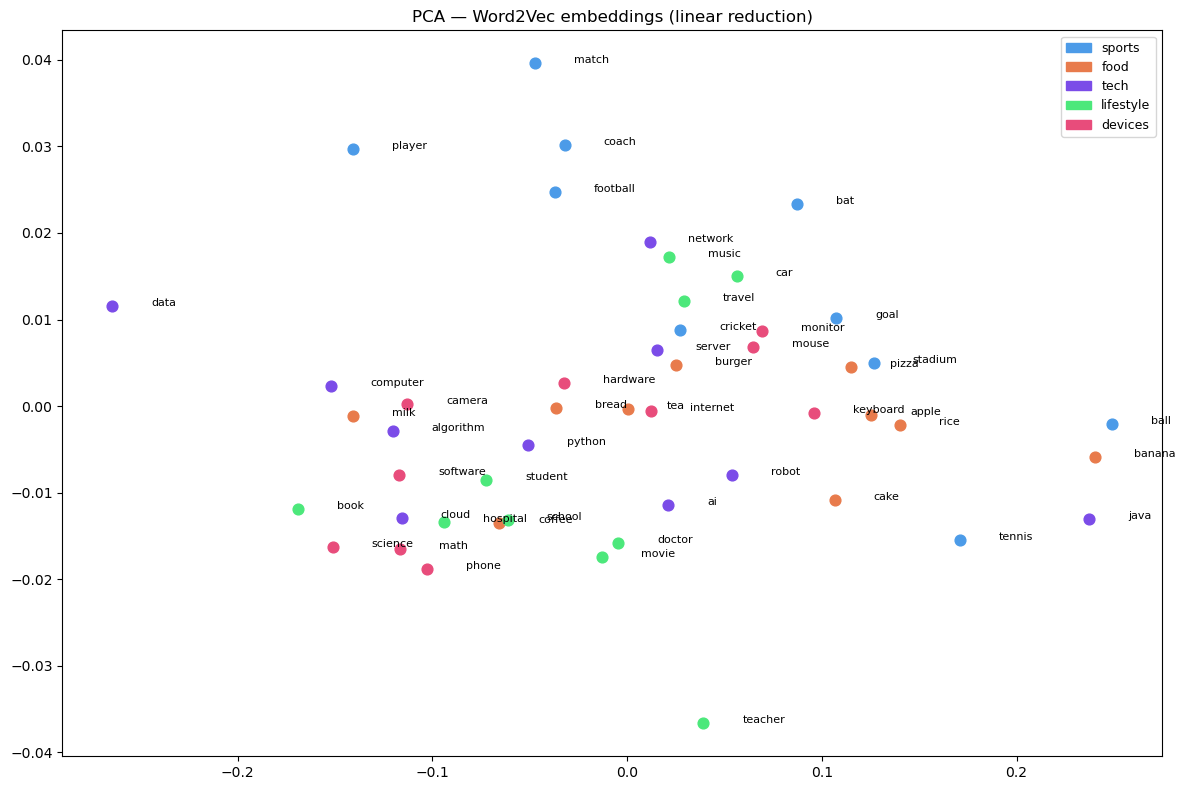

Saved → visualisation/pca_plot.png


In [24]:
# Implementing Principle Component Analysis

"""
Reducing 100-dim vectors to 2D using PCA and plotting.
PCA is linear — fast but may miss curved cluster structure.
Plot is colour-coded by topic group and saved to visualisation/.
"""
# Create the folder automatically if it doesn't exist
os.makedirs('visualisation', exist_ok=True)

coords = PCA(n_components=2).fit_transform(vectors)  # squashes 100 dims → 2 dims linearly

plt.figure(figsize=(12, 8))
for i, w in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=60, zorder=2)   # coloured dot per word
    plt.text(coords[i, 0] + 0.02, coords[i, 1], w, fontsize=8)                 # word label next to dot

# builds the colour legend from GROUP_COLORS defined in dataloader
legend = [mpatches.Patch(color=c, label=grp) for grp, (c, _) in GROUP_COLORS.items()]
plt.legend(handles=legend, loc='upper right', fontsize=9)
plt.title('PCA — Word2Vec embeddings (linear reduction)')
plt.tight_layout()
plt.savefig('visualisation/pca_plot.png', dpi=150)   # saves plot into the visualisation folder
plt.show()
print("Saved → visualisation/pca_plot.png")

## t-SNE Visualization

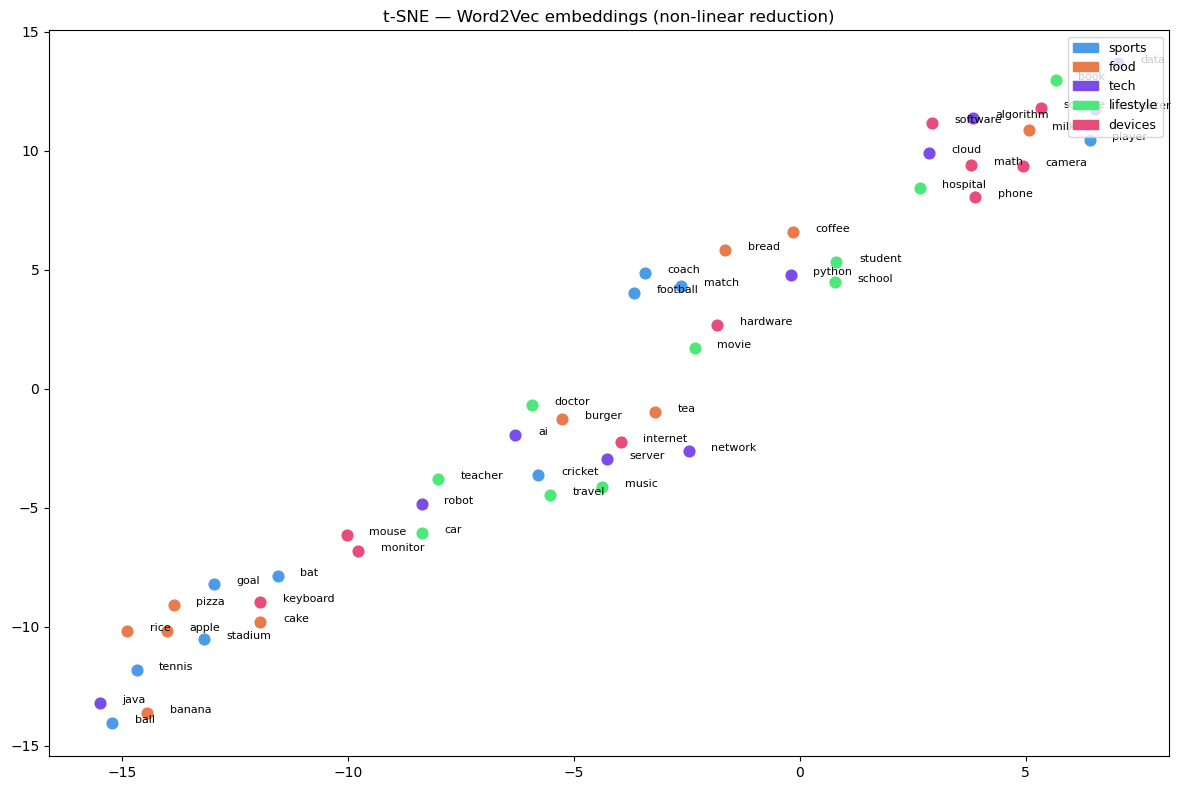

Saved → visualisation/tsne_plot.png


In [25]:
"""
Same idea as PCA but uses t-SNE — a non-linear technique.
Better at revealing tight semantic clusters (sports, food, tech etc.).
Perplexity controls how many neighbours each point considers.
"""

coords = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(vectors)
# random_state=42 → reproducible layout every run
# perplexity=10   → tuned for small sets (rule of thumb: ~5–50, lower for fewer points)

plt.figure(figsize=(12, 8))
for i, w in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=60, zorder=2)   # coloured dot per word
    plt.text(coords[i, 0] + 0.5, coords[i, 1], w, fontsize=8)                  # word label next to dot

legend = [mpatches.Patch(color=c, label=grp) for grp, (c, _) in GROUP_COLORS.items()]
plt.legend(handles=legend, loc='upper right', fontsize=9)
plt.title('t-SNE — Word2Vec embeddings (non-linear reduction)')
plt.tight_layout()
plt.savefig('visualisation/tsne_plot.png', dpi=150)  # saves plot into the visualisation folder
plt.show()
print("Saved → visualisation/tsne_plot.png")

## Saving the Model

In [27]:
import os

# Automatically create the 'models' directory if it's missing
os.makedirs('models', exist_ok=True)

# Now save the model safely
model.save('models/word2vec.model')          
print("Model saved → models/word2vec.model")


Model saved → models/word2vec.model


# Conclusion 

### Observation of Project

* Sports related words appeared closer
* Food words grouped separately
* Tech words has formed their grouped
* Similar words has smaller distance in embedding space

**PCA** preserves global spread — words that are overall far apart in 100D stay far apart. </br>
**t-SNE** preserves local neighbourhoods — same-topic words (sports, food, tech) cluster visually.
* more visible in t-SNE